In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    classification_report
)

In [13]:
# -----------------------------
# 1. Load dataset
# -----------------------------
df = pd.read_csv("diabetic_data.csv")

In [14]:
# -----------------------------
# 2. Create target
# -----------------------------
df["target"] = (df["readmitted"] == "<30").astype(int)

In [15]:
# -----------------------------
# 3. Select features
# -----------------------------
features = [
    "age",
    "time_in_hospital",
    "num_lab_procedures",
    "num_procedures",
    "num_medications",
    "number_outpatient",
    "number_emergency",
    "number_inpatient",
    "number_diagnoses"
]

In [16]:
# Replace ? with NaN
df = df.replace("?", pd.NA)

In [17]:
# Convert age ranges into numeric values

age_mapping = {

    "[0-10)": 5,

    "[10-20)": 15,

    "[20-30)": 25,

    "[30-40)": 35,

    "[40-50)": 45,

    "[50-60)": 55,

    "[60-70)": 65,

    "[70-80)": 75,

    "[80-90)": 85,

    "[90-100)": 95

}

In [18]:
df["age"] = df["age"].map(age_mapping)

In [19]:
# Convert remaining features to numeric

numeric_features = [

    "time_in_hospital",

    "num_lab_procedures",

    "num_procedures",

    "num_medications",

    "number_outpatient",

    "number_emergency",

    "number_inpatient",

    "number_diagnoses"

]

In [20]:
# -----------------------------
# 4. Handle missing values
# -----------------------------
for col in features:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df[features] = df[features].fillna(df[features].median())

In [21]:
# -----------------------------
# 5. X and y
# -----------------------------
X = df[features]
y = df["target"]

# -----------------------------
# 6. Train/test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [22]:
# -----------------------------
# 7. Scaling
# -----------------------------
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
# -----------------------------
# 8. Logistic Regression + L2
# -----------------------------
model = LogisticRegression(
    penalty="l2",
    C=1.0,
    solver="liblinear",
    max_iter=1000
)

In [24]:
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, solver='liblinear')

In [25]:
# -----------------------------
# 9. Probability predictions
# -----------------------------
y_prob = model.predict_proba(X_test_scaled)[:, 1]


In [26]:
# -----------------------------
# 10. ROC-AUC
# -----------------------------
auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.6402119119351146


In [27]:
# -----------------------------
threshold = 0.5
y_pred = (y_prob >= threshold).astype(int)

In [28]:
# -----------------------------
# 12. Confusion Matrix
# -----------------------------
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[18049    34]
 [ 2239    32]]


In [29]:
# -----------------------------
# 13. Classification Report
# -----------------------------
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Classification Report:
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     18083
           1       0.48      0.01      0.03      2271

    accuracy                           0.89     20354
   macro avg       0.69      0.51      0.48     20354
weighted avg       0.84      0.89      0.84     20354



In [30]:
# -----------------------------
# 14. ROC Curve
# -----------------------------
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

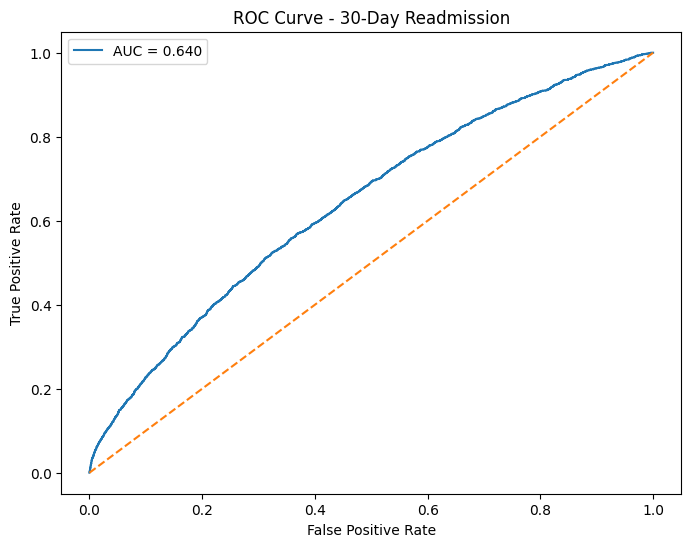

In [31]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - 30-Day Readmission")
plt.legend()
plt.show()

In [32]:
# -----------------------------
# 15. Coefficients
# -----------------------------
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_[0]
})

In [33]:
print("\nCoefficients:")
print(coef_df.sort_values("Coefficient", ascending=False))


Coefficients:
              Feature  Coefficient
7    number_inpatient     0.342948
8    number_diagnoses     0.081029
1    time_in_hospital     0.066300
4     num_medications     0.057803
0                 age     0.055487
6    number_emergency     0.029296
2  num_lab_procedures     0.000120
5   number_outpatient    -0.003387
3      num_procedures    -0.040824
